In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
filePath = 'cleaned_data.csv'
df = pd.read_csv(filePath)
df

,Date,FTHG,FTAG,HTHG,HTAG,Referee,HS,AS,HST,AST,...,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,FTR_A,FTR_D,FTR_H,HTR_A,HTR_D,HTR_H
0,2000-08-19,1.0,0.0,0.0,0.0,Steve Dunn,8.0,14.0,2.0,7.0,...,0,0,0,0,0,0,1,0,1,0
1,2000-08-19,4.0,0.0,2.0,0.0,Rob Harris,17.0,8.0,14.0,4.0,...,0,0,0,0,0,0,1,0,0,1
2,2000-08-19,4.0,2.0,1.0,0.0,Graham Barber,17.0,12.0,10.0,5.0,...,0,1,0,0,0,0,1,0,0,1
3,2000-08-19,1.0,3.0,1.0,1.0,Barry Knight,6.0,16.0,3.0,9.0,...,0,0,0,0,1,0,0,0,1,0
4,2000-08-19,2.0,2.0,1.0,2.0,Andy D'Urso,6.0,13.0,4.0,6.0,...,0,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8713,2023-12-30,2.0,0.0,1.0,0.0,D Coote,18.0,4.0,4.0,2.0,...,0,0,0,0,0,0,1,0,0,1
8714,2023-12-31,2.0,1.0,1.0,1.0,J Smith,15.0,13.0,4.0,3.0,...,0,0,0,0,0,0,1,0,1,0
8715,2023-12-31,3.0,1.0,1.0,0.0,S Hooper,12.0,24.0,6.0,4.0,...,0,0,0,0,0,0,1,0,0,1
8716,2024-01-01,4.0,2.0,0.0,0.0,A Taylor,34.0,5.0,15.0,3.0,...,0,0,0,0,0,0,1,0,1,0


              precision    recall  f1-score   support

           0       0.63      0.60      0.62       869
           1       0.62      0.65      0.64       875

    accuracy                           0.63      1744
   macro avg       0.63      0.63      0.63      1744
weighted avg       0.63      0.63      0.63      1744



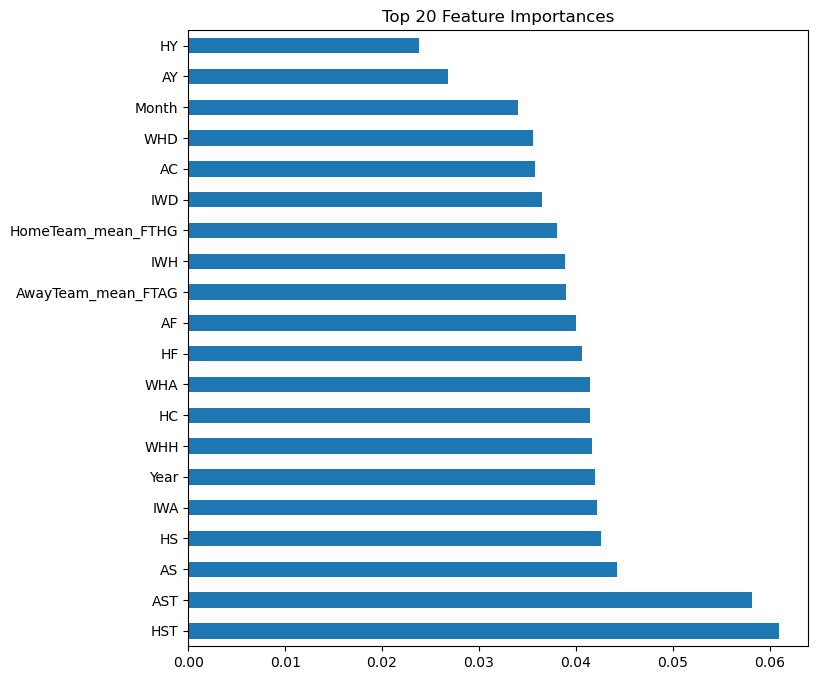

In [6]:
cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',  
    'HTHG', 'HTAG',                               
    'FTR_H', 'FTR_A', 'FTR_D',                   
    'HTR_H', 'HTR_A', 'HTR_D',                   
    'Date', 'Referee'                          
   
]

X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['GoalsOver2_5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances')
plt.show()